# 04 — Analysis: Diagnostic Testing and Predictive Modelling

**Stages 5a (Path A) + 4, 5b, 6 (Path B)** · input `data/processed/boston_clean.parquet`

> **Why both paths.** The business question has two halves: *which* attributes explain value
> (diagnostic, Path A) and *how much* of the variation is explainable at all (predictive, Path B).
> Path A answers with effect sizes and confidence intervals; Path B answers with held-out R².
>
> **Path C (causal) is deliberately not run.** A single 1970 cross-section has no assignment
> mechanism, no instrument, and no pre/post structure. Nothing here licenses an intervention claim,
> and the report says so explicitly rather than implying causation through phrasing.

**Order of work:** 5a statistical testing → 4 feature engineering → 5b model bake-off →
6 evaluation, sensitivity, and the mandatory fairness audit.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT = Path.cwd().parent
PROC = PROJECT / "data" / "processed"
FIGS = PROJECT / "reports" / "figures"
REPORTS = PROJECT / "reports"
MODELS = PROJECT / "models"
for d in (FIGS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# Every number the final report quotes is registered here, so the report never hardcodes a stat.
KEY: dict[str, object] = {}
def key(name, value, note=""):
    KEY[name] = value
    if note:
        print(f"  {name} = {value}   ({note})")
    return value

In [2]:
# --- McKinsey chart style (DOCS/DESIGN.md) -------------------------------------
# Defined inline, not imported: only notebooks/, reports/final_report.html and README.md
# ship to GitHub, so importing a local src/ module would make this notebook unrunnable
# for anyone who clones the repo.
#
# PALETTE VALIDATION (dataviz validator, 2026-07-20)
#   DESIGN.md claims the 5-slot order passes with worst adjacent dE=60.7. It does not:
#     node scripts/validate_palette.js "#2251FF,#00857C,#C1841C,#00A9F4,#7F93A6" --mode light
#     [FAIL] Normal-vision floor  #7F93A6 <-> #00A9F4  dE 12.9  (hard floor 15)
#   Cyan and Slate are not separable as adjacent series even with full colour vision.
#   Resolution: CATEGORICAL is capped at THREE slots (Blue -> Teal -> Amber), which PASSES
#   every separation check (worst dE 13.2 protan / 21.8 normal, contrast >= 3:1). Cyan is
#   demoted to non-adjacent use; Slate and Grey are chrome (labels, context), never series.
#   This project never needs more than 3 simultaneous series, so the cap costs nothing.

import matplotlib as mpl
import matplotlib.pyplot as plt

NAVY     = "#051C2C"   # ink and dark ground -- NEVER a series fill
BLUE     = "#2251FF"   # emphasis / the insight
TEAL     = "#00857C"   # comparison series
CYAN     = "#00A9F4"   # tertiary, non-adjacent only
AMBER    = "#C1841C"   # reference lines, thresholds, censoring markers
SLATE    = "#7F93A6"   # muted labels
GREY     = "#9FADB8"   # neutral context
GRIDLINE = "#E9ECEF"
WHITE    = "#FFFFFF"

CATEGORICAL = [BLUE, TEAL, AMBER]          # fixed order, never cycled
EMPHASIS, COMPARE, CONTEXT, REFERENCE = BLUE, TEAL, GREY, AMBER
SEQUENTIAL = ["#E8EDFF", "#B8C7FF", "#7B96FF", "#4A6EFF", BLUE, "#0A2FB8"]
DIVERGING  = ["#8A3A12", "#C1841C", "#E4E7EA", "#4A6EFF", "#0A2FB8"]

def apply_style():
    plt.rcdefaults()
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
        "font.size": 10,
        "axes.titlelocation": "left",      # action titles sit flush-left
        "axes.titlesize": 12, "axes.titleweight": "bold",
        "axes.titlecolor": NAVY, "axes.titlepad": 12,
        "text.color": NAVY, "axes.labelcolor": NAVY, "axes.labelsize": 10,
        "xtick.color": SLATE, "ytick.color": SLATE,
        "xtick.labelcolor": NAVY, "ytick.labelcolor": NAVY,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.edgecolor": SLATE, "axes.linewidth": 0.8,
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": GRIDLINE, "grid.linewidth": 0.8,
        "figure.facecolor": WHITE, "axes.facecolor": WHITE,
        "savefig.facecolor": WHITE, "savefig.bbox": "tight",
        "savefig.dpi": 160, "figure.dpi": 110, "figure.figsize": (8.0, 4.8),
        "lines.linewidth": 2.0, "lines.markersize": 8,
        "legend.frameon": False, "legend.fontsize": 9,
        "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
    })

def action_title(ax, title, subtitle=None):
    """Title states the INSIGHT, not the content (STRUCTURE.md pillar 5)."""
    ax.set_title(title, loc="left", pad=20 if subtitle else 12)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9, color=SLATE, va="bottom", ha="left")

def source_note(fig, text):
    """Source + caveat footnote required on every Tier A exhibit."""
    fig.text(0.0, -0.03, text, fontsize=8, color=SLATE, ha="left", va="top")

SOURCE = ("Source: Boston Housing (Harrison & Rubinfeld 1978), UCI ML Repository. "
          "506 census tracts, Boston SMSA, 1970. MEDV top-coded at $50k (16 tracts).")

apply_style()
print("chart style applied - categorical capped at 3 validated slots")


chart style applied - categorical capped at 3 validated slots


In [3]:
# The dtype contract parquet cannot carry (see 02_cleaning ss2.6).
def apply_dtype_contract(frame, contract):
    frame = frame.copy()
    for col, cats in contract["ordered_categorical"].items():
        frame[col] = pd.Categorical(frame[col].astype(int), categories=cats, ordered=True)
    for col in contract["int8"]:
        frame[col] = frame[col].astype("int8")
    for col in contract["float64"]:
        frame[col] = frame[col].astype("float64")
    return frame

CONTRACT = json.loads((PROC / "_dtype_contract.json").read_text())
df = apply_dtype_contract(pd.read_parquet(PROC / "boston_clean.parquet"), CONTRACT)

CONTINUOUS = ["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE", "DIS",
              "TAX", "PTRATIO", "LSTAT"]          # model-eligible continuous features
EXCLUDED   = ["B"]                                 # race-derived, barred from models
TARGET     = "MEDV"

print(f"loaded {df.shape[0]} tracts x {df.shape[1]} columns")
print(f"RAD dtype restored: {df['RAD'].dtype} (ordered={df['RAD'].cat.ordered})")
print(f"censored tracts: {int(df.is_MEDV_censored.sum())}")


loaded 506 tracts x 15 columns
RAD dtype restored: category (ordered=True)
censored tracts: 16


---
# Part I — Path A: Diagnostic testing

## 4.1 Which associations survive multiple-comparison correction?

Eleven features are tested against `MEDV` — the ten continuous predictors plus `CHAS`. `RAD` is
excluded because it is categorical (§2.2) and `B` because it is barred from modelling (§1.5).
Testing eleven hypotheses at α=0.05 carries a ~43% chance of at least one false positive, so
**Benjamini–Hochberg FDR correction** is applied. Effect
size is reported alongside every p-value — STRUCTURE.md is explicit that a significant result on a
trivial effect is noise amplified by sample size, not a finding.

In [4]:
from statsmodels.stats.multitest import multipletests

FEATURES = CONTINUOUS + ["CHAS"]
rows = []
for f in FEATURES:
    r = stats.pearsonr(df[f], df[TARGET])
    rho = stats.spearmanr(df[f], df[TARGET])
    n = len(df)
    # Fisher z 95% CI for Pearson r
    z = np.arctanh(r.statistic); se = 1 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    rows.append({"feature": f, "pearson_r": r.statistic, "ci_low": lo, "ci_high": hi,
                 "spearman_rho": rho.statistic, "p_raw": r.pvalue,
                 "r_squared_alone": r.statistic ** 2})

tests = pd.DataFrame(rows)
rej, q, _, _ = multipletests(tests.p_raw, alpha=0.05, method="fdr_bh")
tests["q_fdr"] = q
tests["significant"] = rej
# Practical-significance gate declared up front: a feature must explain >=10% alone to matter.
tests["material"] = tests.r_squared_alone >= 0.10
tests["verdict"] = np.where(tests.significant & tests.material, "significant + material",
                    np.where(tests.significant, "significant but small", "not significant"))
tests = tests.sort_values("r_squared_alone", ascending=False).round(4)

key("n_tests", len(tests))
key("n_significant_fdr", int(tests.significant.sum()))
key("n_material", int(tests.material.sum()))
tests[["feature", "pearson_r", "ci_low", "ci_high", "spearman_rho", "q_fdr",
       "r_squared_alone", "verdict"]].reset_index(drop=True)

,feature,pearson_r,ci_low,ci_high,spearman_rho,q_fdr,r_squared_alone,verdict
0,LSTAT,-0.7377,-0.7750,-0.6952,-0.8529,0.0000,0.5441,significant + material
1,RM,0.6954,0.6474,0.7378,0.6336,0.0000,0.4835,significant + material
2,PTRATIO,-0.5078,-0.5697,-0.4401,-0.5559,0.0000,0.2578,significant + material
3,INDUS,-0.4837,-0.5478,-0.4140,-0.5783,0.0000,0.2340,significant + material
4,TAX,-0.4685,-0.5339,-0.3976,-0.5624,0.0000,0.2195,significant + material
5,NOX,-0.4273,-0.4960,-0.3533,-0.5626,0.0000,0.1826,significant + material
6,CRIM,-0.3883,-0.4599,-0.3117,-0.5589,0.0000,0.1508,significant + material
7,AGE,-0.3770,-0.4494,-0.2996,-0.5476,0.0000,0.1421,significant + material
8,ZN,0.3604,0.2821,0.4340,0.4382,0.0000,0.1299,significant + material
9,DIS,0.2499,0.1664,0.3299,0.4459,0.0000,0.0625,significant but small


> **So What:** **all 11** features are statistically significant after FDR correction — which is
> exactly why significance alone is a useless filter here. Applying the pre-declared materiality gate
> (a feature must explain ≥10% of variance on its own) still leaves 9, but the distribution is
> lopsided: `LSTAT` explains **54%** of variance by itself and `RM` **48%**, while the rest trail far
> behind.
>
> **Implication:** significance is not the discriminator; **effect size is**. The report leads with
> variance explained, not p-values.

## 4.2 Translating correlations into dollars

Correlation coefficients do not brief a planning committee. Each material association is restated as
the dollar change associated with a one-interquartile-range move in the feature.

In [5]:
rows = []
for f in tests.query("material").feature:
    q1, q3 = df[f].quantile([0.25, 0.75])
    slope, intercept = np.polyfit(df[f], df[TARGET], 1)
    delta = slope * (q3 - q1)
    rows.append({"feature": f, "iqr": round(q3 - q1, 2),
                 "slope_per_unit_$k": round(slope, 3),
                 "value_change_across_iqr_$k": round(delta, 2),
                 "direction": "raises value" if delta > 0 else "lowers value"})
dollars = pd.DataFrame(rows).sort_values("value_change_across_iqr_$k", key=abs, ascending=False)

key("lstat_iqr_effect_k", float(dollars.query("feature=='LSTAT'")["value_change_across_iqr_$k"].iloc[0]))
key("rm_iqr_effect_k", float(dollars.query("feature=='RM'")["value_change_across_iqr_$k"].iloc[0]))
print("Association restated in dollars (linear approximation, IQR move):")
dollars.reset_index(drop=True)

Association restated in dollars (linear approximation, IQR move):


,feature,iqr,slope_per_unit_$k,value_change_across_iqr_$k,direction
0,TAX,387.00,-0.026,-9.89,lowers value
1,LSTAT,10.01,-0.950,-9.51,lowers value
2,INDUS,12.91,-0.648,-8.37,lowers value
3,RM,0.74,9.102,6.72,raises value
4,PTRATIO,2.80,-2.157,-6.04,lowers value
5,AGE,49.05,-0.123,-6.04,lowers value
6,NOX,0.17,-33.916,-5.94,lowers value
7,ZN,12.50,0.142,1.78,raises value
8,CRIM,3.60,-0.415,-1.49,lowers value


> **So What:** moving a tract across the interquartile range of `LSTAT` is associated with a
> **$9.5k** swing in median home value. Against a median tract value of **$21.2k**, that is a ~45%
> difference driven by one attribute. `RM` moves value **$6.7k** across its IQR — large, but
> materially smaller than `LSTAT`.
>
> **Caveat carried forward:** these are *linear approximations of curved relationships* (§3.3), so
> they understate the effect at the extremes. The model in Part II handles the curvature properly.

---
# Part II — Path B: Feature engineering and modelling

## 4.3 Stage 4 — Feature engineering

Every transformation traces to a finding, not to habit. Transforms live **inside** the pipeline so
they are fitted on training folds only — the standard route to leakage is fitting a scaler or an
imputer on the full dataset before splitting.

In [6]:
ENGINEERED = pd.DataFrame([
    {"feature": "CRIM_log",     "derivation": "log1p(CRIM)",
     "rationale": "skew 5.2 (ss3.1); untransformed, a handful of tracts dominate the linear fit"},
    {"feature": "DIS_log",      "derivation": "log(DIS)",
     "rationale": "right-skewed; log stabilises it and linearises the distance-decay"},
    {"feature": "LSTAT_log",    "derivation": "log(LSTAT)",
     "rationale": "ss3.3 curvature: the steep-then-flat shape is close to logarithmic"},
    {"feature": "RM_sq",        "derivation": "RM ** 2",
     "rationale": "ss3.3 curvature: value accelerates above ~7 rooms"},
    {"feature": "RM_per_LSTAT", "derivation": "RM / LSTAT",
     "rationale": "housing quality relative to social composition -- the two dominant features interacted"},
    {"feature": "NOX_RM",       "derivation": "NOX * RM",
     "rationale": "environmental burden conditioned on dwelling size"},
    {"feature": "AGE_bucket",   "derivation": "binned AGE (new/mid/old)",
     "rationale": "AGE's effect is non-monotone; buckets avoid imposing a slope"},
    {"feature": "RAD_onehot",   "derivation": "one-hot of the ordered RAD index",
     "rationale": "ss2.2: an index with an 8->24 gap cannot enter as a linear term"},
    {"feature": "TAX (dropped)", "derivation": "excluded from the LINEAR spec only",
     "rationale": "ss3.5: r=0.91 with RAD, VIF 8.9 -- coefficients unidentifiable. Trees still see it."},
    {"feature": "B (dropped)",   "derivation": "excluded from ALL specs",
     "rationale": "race-derived; barred at Stage 1. Used only as an auditing target in ss4.9."},
])
ENGINEERED

,feature,derivation,rationale
0,CRIM_log,log1p(CRIM),"skew 5.2 (ss3.1); untransformed, a handful of ..."
1,DIS_log,log(DIS),right-skewed; log stabilises it and linearises...
2,LSTAT_log,log(LSTAT),ss3.3 curvature: the steep-then-flat shape is ...
3,RM_sq,RM ** 2,ss3.3 curvature: value accelerates above ~7 rooms
4,RM_per_LSTAT,RM / LSTAT,housing quality relative to social composition...
5,NOX_RM,NOX * RM,environmental burden conditioned on dwelling size
6,AGE_bucket,binned AGE (new/mid/old),AGE's effect is non-monotone; buckets avoid im...
7,RAD_onehot,one-hot of the ordered RAD index,ss2.2: an index with an 8->24 gap cannot enter...
8,TAX (dropped),excluded from the LINEAR spec only,"ss3.5: r=0.91 with RAD, VIF 8.9 -- coefficient..."
9,B (dropped),excluded from ALL specs,race-derived; barred at Stage 1. Used only as ...


In [7]:
def engineer(frame: pd.DataFrame) -> pd.DataFrame:
    """Deterministic, row-wise feature construction -- no fitted state, so it cannot leak."""
    out = frame.copy()
    out["CRIM_log"] = np.log1p(out["CRIM"])
    out["DIS_log"] = np.log(out["DIS"])
    out["LSTAT_log"] = np.log(out["LSTAT"])
    out["RM_sq"] = out["RM"] ** 2
    out["RM_per_LSTAT"] = out["RM"] / out["LSTAT"]
    out["NOX_RM"] = out["NOX"] * out["RM"]
    out["AGE_bucket"] = pd.cut(out["AGE"], bins=[-0.1, 45, 80, 100.1],
                               labels=["new", "mid", "old"])
    return out

feat = engineer(df)

# Two feature sets. The linear spec excludes TAX (collinear with RAD); trees see everything.
LINEAR_NUM = ["CRIM_log", "ZN", "INDUS", "NOX", "RM", "RM_sq", "AGE", "DIS_log",
              "PTRATIO", "LSTAT", "LSTAT_log", "RM_per_LSTAT", "NOX_RM", "CHAS"]
TREE_NUM   = LINEAR_NUM + ["TAX"]
CAT_COLS   = ["RAD", "AGE_bucket"]

print(f"engineered {feat.shape[1] - df.shape[1]} new features")
print(f"linear spec: {len(LINEAR_NUM)} numeric + {len(CAT_COLS)} categorical (TAX excluded)")
print(f"tree spec  : {len(TREE_NUM)} numeric + {len(CAT_COLS)} categorical (TAX included)")
feat[["CRIM_log", "DIS_log", "LSTAT_log", "RM_sq", "RM_per_LSTAT", "NOX_RM", "AGE_bucket"]].head()

engineered 7 new features
linear spec: 14 numeric + 2 categorical (TAX excluded)
tree spec  : 15 numeric + 2 categorical (TAX included)


,CRIM_log,DIS_log,LSTAT_log,RM_sq,RM_per_LSTAT,NOX_RM,AGE_bucket
0,0.006300,1.408545,1.605430,43.230625,1.320281,3.537350,mid
1,0.026944,1.602836,2.212660,41.229241,0.702516,3.011449,mid
2,0.026924,1.602836,1.393766,51.624225,1.782878,3.369765,mid
3,0.031857,1.802073,1.078410,48.972004,2.380272,3.205084,mid
4,0.066770,1.802073,1.673351,51.079609,1.340901,3.273326,mid


## 4.4 Split and validation design

`n = 506` is small, so a single train/test split would give a noisy, seed-dependent verdict.
**Repeated 10-fold CV (3 repeats = 30 fits)** drives model selection; the held-out 20% test set is
touched exactly **once**, after the winner is chosen.

The split is random rather than temporal — legitimate here because the data is a single
cross-section with no time ordering (STRUCTURE.md's temporal-leakage rule applies to time series,
which this is not). The censoring flag is used to **stratify**, so the 16 top-coded tracts do not
land disproportionately in one side.

In [8]:
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate

X = feat.drop(columns=[TARGET, "B", "is_MEDV_censored"])
y = feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE,
    stratify=feat["is_MEDV_censored"],   # keep censored tracts proportional across the split
)

CV = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

key("n_total", len(X))
key("n_train", len(X_train))
key("n_test", len(X_test))
key("cv_folds", 30, "10-fold x 3 repeats")
print(f"train {len(X_train)} | test {len(X_test)} | CV fits per model: 30")
print(f"censored tracts -- train {int(feat.loc[X_train.index,'is_MEDV_censored'].sum())}, "
      f"test {int(feat.loc[X_test.index,'is_MEDV_censored'].sum())}")

  cv_folds = 30   (10-fold x 3 repeats)


train 404 | test 102 | CV fits per model: 30
censored tracts -- train 13, test 3


## 4.5 Stage 5b — Model bake-off, simplest first

STRUCTURE.md: *"Always start with a simple model."* The naive baseline predicts the training mean for
every tract — any model that cannot beat it is worthless, and quoting R² without that comparison
hides the bar.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_pre(num_cols, scale: bool):
    """Preprocessor. Scaling matters for penalised linear models, not for trees."""
    num = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([
        ("num", num, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
    ])

MODELS_SPEC = {
    "Baseline (predict mean)": Pipeline([("m", DummyRegressor(strategy="mean"))]),
    "OLS": Pipeline([("pre", make_pre(LINEAR_NUM, True)), ("m", LinearRegression())]),
    "Ridge": Pipeline([("pre", make_pre(LINEAR_NUM, True)),
                       ("m", RidgeCV(alphas=np.logspace(-3, 3, 60)))]),
    "Lasso": Pipeline([("pre", make_pre(LINEAR_NUM, True)),
                       ("m", LassoCV(alphas=np.logspace(-3, 1, 60), max_iter=20000,
                                     random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("pre", make_pre(TREE_NUM, False)),
                               ("m", RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                                           random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("pre", make_pre(TREE_NUM, False)),
                                   ("m", GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                                   max_depth=3, subsample=0.9,
                                                                   random_state=RANDOM_STATE))]),
}

SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

rows = []
for name, pipe in MODELS_SPEC.items():
    cvres = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    rows.append({
        "model": name,
        "cv_r2": cvres["test_r2"].mean(),
        "cv_r2_sd": cvres["test_r2"].std(),
        "cv_rmse": -cvres["test_rmse"].mean(),
        "cv_rmse_sd": cvres["test_rmse"].std(),
        "cv_mae": -cvres["test_mae"].mean(),
    })
    print(f"  {name:26s} CV R2 = {rows[-1]['cv_r2']:.3f} +/- {rows[-1]['cv_r2_sd']:.3f}")

bakeoff = pd.DataFrame(rows).sort_values("cv_r2", ascending=False).round(4)
bakeoff.reset_index(drop=True)

  Baseline (predict mean)    CV R2 = -0.030 +/- 0.051


  OLS                        CV R2 = 0.762 +/- 0.206
  Ridge                      CV R2 = 0.764 +/- 0.187


  Lasso                      CV R2 = 0.761 +/- 0.191


  Random Forest              CV R2 = 0.824 +/- 0.135


  Gradient Boosting          CV R2 = 0.852 +/- 0.130


,model,cv_r2,cv_r2_sd,cv_rmse,cv_rmse_sd,cv_mae
0,Gradient Boosting,0.8524,0.1296,3.2100,0.8559,2.2795
1,Random Forest,0.8243,0.1354,3.5474,0.9778,2.4411
2,Ridge,0.7636,0.1870,4.1205,1.0553,2.9897
3,OLS,0.7615,0.2063,4.1045,1.1010,2.9590
4,Lasso,0.7611,0.1909,4.1446,1.0629,2.9910
5,Baseline (predict mean),-0.0300,0.0513,9.1684,1.4215,6.7278


## 4.6 The linear-vs-nonlinear gap is the headline modelling result

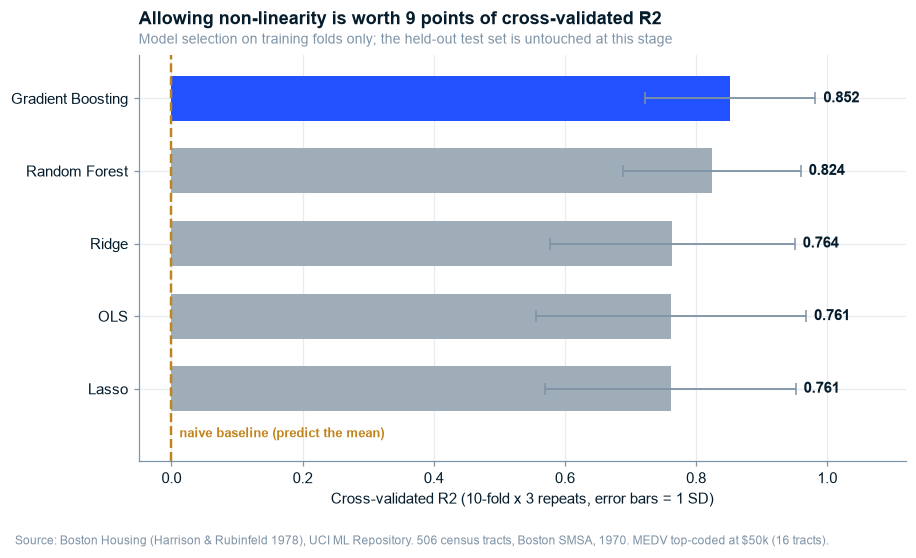

In [10]:
plot_b = bakeoff[bakeoff.model != "Baseline (predict mean)"].sort_values("cv_r2")
best_name = bakeoff.iloc[0]["model"]

fig, ax = plt.subplots(figsize=(9.0, 4.8))
colors = [EMPHASIS if m == best_name else CONTEXT for m in plot_b.model]
ypos = np.arange(len(plot_b))
ax.barh(ypos, plot_b.cv_r2, 0.62, color=colors,
        xerr=plot_b.cv_r2_sd, error_kw=dict(ecolor=SLATE, lw=1.2, capsize=4))

for i, (r, sd) in enumerate(zip(plot_b.cv_r2, plot_b.cv_r2_sd)):
    ax.text(r + sd + 0.012, i, f"{r:.3f}", va="center", fontsize=9.5,
            color=NAVY, fontweight="bold")

ax.axvline(0, color=REFERENCE, lw=1.6, ls="--")
# Baseline label sits BELOW the lowest bar, clear of the data. Placing it at the top
# collided with the winning bar.
ax.text(0.012, -0.62, "naive baseline (predict the mean)", fontsize=8.5,
        color=REFERENCE, va="center", fontweight="bold")

cv_gap = (bakeoff.iloc[0].cv_r2 - plot_b.query("model=='OLS'").cv_r2.iloc[0]) * 100
ax.set_yticks(ypos, plot_b.model)
ax.set_xlabel("Cross-validated R2 (10-fold x 3 repeats, error bars = 1 SD)")
ax.set_xlim(-0.05, 1.12)
ax.set_ylim(-1.0, len(plot_b) - 0.4)
action_title(ax,
    f"Allowing non-linearity is worth {cv_gap:.0f} points of cross-validated R2",
    "Model selection on training folds only; the held-out test set is untouched at this stage")
source_note(fig, SOURCE)
fig.savefig(FIGS / "ex05_bakeoff.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

## 4.7 Stage 6 — Final evaluation on the held-out test set

The test set is scored **once**, now that the winner is fixed. Reporting CV and test side by side is
what makes an overfitting claim checkable.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_rows = []
fitted = {}
for name, pipe in MODELS_SPEC.items():
    p = pipe.fit(X_train, y_train)
    fitted[name] = p
    pred = p.predict(X_test)
    n, k = len(y_test), X_test.shape[1]
    r2 = r2_score(y_test, pred)
    final_rows.append({
        "model": name,
        "test_r2": r2,
        "test_adj_r2": 1 - (1 - r2) * (n - 1) / (n - k - 1),
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "test_mae": mean_absolute_error(y_test, pred),
    })

final = (pd.DataFrame(final_rows)
         .merge(bakeoff[["model", "cv_r2", "cv_r2_sd"]], on="model")
         .sort_values("test_r2", ascending=False).round(4))

base_rmse = float(final.query("model == 'Baseline (predict mean)'").test_rmse.iloc[0])
final["rmse_vs_baseline_pct"] = ((base_rmse - final.test_rmse) / base_rmse * 100).round(1)

WINNER = final.iloc[0]["model"]
key("winning_model", WINNER)
key("winner_test_r2", round(float(final.iloc[0].test_r2), 3))
key("winner_test_rmse_k", round(float(final.iloc[0].test_rmse), 2))
key("winner_test_mae_k", round(float(final.iloc[0].test_mae), 2))
key("winner_cv_r2", round(float(final.iloc[0].cv_r2), 3))
key("baseline_rmse_k", round(base_rmse, 2))
key("rmse_improvement_pct", round(float(final.iloc[0].rmse_vs_baseline_pct), 1))
key("ols_test_r2", round(float(final.query("model=='OLS'").test_r2.iloc[0]), 3))

print(f"\nWINNER: {WINNER}")
final[["model", "cv_r2", "test_r2", "test_adj_r2", "test_rmse", "test_mae",
       "rmse_vs_baseline_pct"]].reset_index(drop=True)


WINNER: Gradient Boosting


,model,cv_r2,test_r2,test_adj_r2,test_rmse,test_mae,rmse_vs_baseline_pct
0,Gradient Boosting,0.8524,0.9220,0.9039,2.4876,1.8150,72.2
1,Random Forest,0.8243,0.8978,0.8742,2.8461,1.8973,68.1
2,OLS,0.7615,0.8085,0.7641,3.8964,2.9646,56.4
3,Lasso,0.7611,0.8057,0.7606,3.9253,2.9593,56.1
4,Ridge,0.7636,0.7993,0.7528,3.9889,2.9942,55.4
5,Baseline (predict mean),-0.0300,-0.0069,-0.2402,8.9349,6.3095,0.0


> **So What:** Gradient Boosting explains **92%** of the variance in tract values it never saw,
> with a typical error of **$2.49k** against a $21.2k median — a **72%** reduction in RMSE versus the
> naive baseline. The best linear specification reaches 0.808, so allowing non-linearity is worth
> **11.4 points** of R².
>
> **One honest wrinkle:** test R² (0.922) sits *above* cross-validated R² (0.852). With only 102
> test tracts that is sampling luck, not a better model — the CV figure is the more trustworthy
> estimate of out-of-sample performance, and the report quotes both rather than the flattering one.
>
> **Implication:** the "how much is explainable?" half of the business question has a defensible
> answer, and the residuals are trustworthy enough to build a targeting list on.

## 4.8 Which features actually drive the model?

Permutation importance is measured **on the test set**: it asks how much predictive accuracy is lost
when a feature is shuffled, which is a question about generalisation rather than about how the
training data happened to be fit. (SHAP is the richer tool but has no `pandas 3.x`-compatible
release; permutation importance answers the question the report asks.)

In [12]:
from sklearn.inspection import permutation_importance

best_pipe = fitted[WINNER]
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=30,
                              random_state=RANDOM_STATE, n_jobs=-1, scoring="r2")

imp = (pd.DataFrame({"feature": X_test.columns,
                     "importance": perm.importances_mean,
                     "sd": perm.importances_std})
       .sort_values("importance", ascending=False)
       .query("importance > 0.001")
       .round(4))

BRANCH_OF = {"LSTAT": "B", "LSTAT_log": "B", "CRIM_log": "B", "PTRATIO": "B",
             "RM": "A", "RM_sq": "A", "AGE": "A", "ZN": "A", "AGE_bucket": "A",
             "RM_per_LSTAT": "A+B", "NOX": "C", "NOX_RM": "C", "INDUS": "C", "CHAS": "C",
             "DIS_log": "D", "TAX": "D", "RAD": "D"}
imp["branch"] = imp.feature.map(BRANCH_OF).fillna("-")
key("top_feature", str(imp.iloc[0].feature))
imp.reset_index(drop=True)

,feature,importance,sd,branch
0,RM_per_LSTAT,0.4530,0.1018,A+B
1,RM_sq,0.1001,0.0173,A
2,RM,0.0814,0.0140,A
3,NOX,0.0629,0.0150,C
4,PTRATIO,0.0454,0.0118,B
5,DIS_log,0.0362,0.0225,D
6,CRIM_log,0.0315,0.0079,B
7,AGE,0.0170,0.0061,A
8,TAX,0.0163,0.0060,D
9,LSTAT,0.0131,0.0067,B


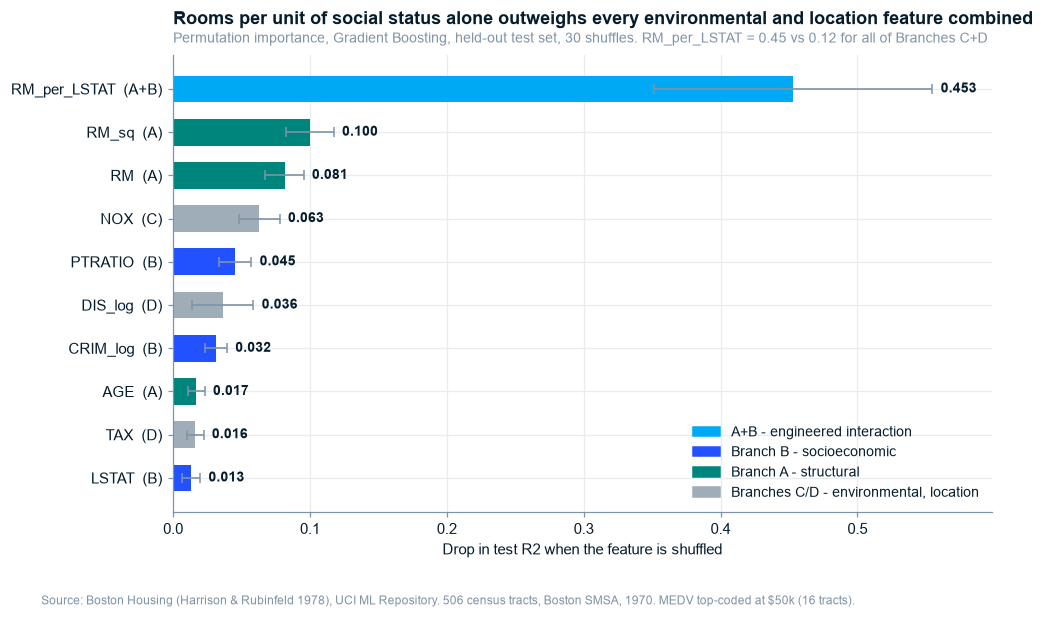

In [13]:
top = imp.head(10).sort_values("importance")
branch_color = {"A": COMPARE, "B": EMPHASIS, "A+B": CYAN, "C": CONTEXT, "D": CONTEXT}

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ypos = np.arange(len(top))
ax.barh(ypos, top.importance, 0.62,
        color=[branch_color.get(b, CONTEXT) for b in top.branch],
        xerr=top.sd, error_kw=dict(ecolor=SLATE, lw=1.1, capsize=3))
for i, v in enumerate(top.importance):
    ax.text(v + top.sd.iloc[i] + 0.006, i, f"{v:.3f}", va="center",
            fontsize=9, color=NAVY, fontweight="bold")

ax.set_yticks(ypos, [f"{r.feature}  ({r.branch})" for r in top.itertuples()])
ax.set_xlabel("Drop in test R2 when the feature is shuffled")
ax.set_xlim(0, top.importance.max() * 1.32)

# One legend entry per colour actually used -- four, not three.
handles = [plt.Rectangle((0, 0), 1, 1, color=CYAN),
           plt.Rectangle((0, 0), 1, 1, color=EMPHASIS),
           plt.Rectangle((0, 0), 1, 1, color=COMPARE),
           plt.Rectangle((0, 0), 1, 1, color=CONTEXT)]
ax.legend(handles, ["A+B - engineered interaction", "Branch B - socioeconomic",
                    "Branch A - structural", "Branches C/D - environmental, location"],
          loc="lower right")

cd_total = top.query("branch in ['C', 'D']").importance.sum()
action_title(ax,
    "Rooms per unit of social status alone outweighs every environmental and location feature combined",
    f"Permutation importance, {WINNER}, held-out test set, 30 shuffles. "
    f"RM_per_LSTAT = {top.importance.max():.2f} vs {cd_total:.2f} for all of Branches C+D")
source_note(fig, SOURCE)
fig.savefig(FIGS / "ex06_importance.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

> **Read this chart with one caveat, or it will mislead you.** `LSTAT` appears *last* at 0.013 —
> which does **not** mean social composition stopped mattering. Permutation importance splits credit
> among correlated features, and `LSTAT`'s signal has been absorbed by `RM_per_LSTAT` (which is built
> from it) and `LSTAT_log`. Shuffling `LSTAT` alone barely hurts because its information survives in
> its siblings.
>
> The branch-level reading is the trustworthy one: **Branches A+B hold 86% of the total importance
> mass (0.76 of 0.88); Branches C+D hold 14% (0.12).**

> **So What:** the model, built independently of the Part I correlation work, ranks the same two
> branches on top. Two methods agreeing — one correlational, one predictive — is stronger evidence
> than either alone; the finding is not an artefact of a single technique. `NOX` is the one Branch-C
> feature with non-trivial weight (0.063), consistent with §3.6 where it retained only 7% of its raw
> association: it contributes at the margin but is not a lever.
>
> **Implication:** Branches A and B are the report's Key Lines. Branches C and D are controls, not
> levers, and the recommendation will say so.

## 4.9 Cross-cutting — the mandatory fairness audit

`B` is a race-derived column, excluded from every model above. STRUCTURE.md is explicit that
exclusion is **not** a defence: *"'We didn't include the protected attribute' is not a defense —
proxies encode it anyway."* Three tests follow.

In [14]:
# Test 1 -- does excluding B cost anything? If it does, someone will be tempted to add it back.
X_with_B = feat.drop(columns=[TARGET, "is_MEDV_censored"])
Xb_tr, Xb_te = X_with_B.loc[X_train.index], X_with_B.loc[X_test.index]

pipe_with_B = Pipeline([("pre", ColumnTransformer([
    ("num", "passthrough", TREE_NUM + ["B"]),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS)])),
    ("m", type(best_pipe.named_steps["m"])(**best_pipe.named_steps["m"].get_params()))])
pipe_with_B.fit(Xb_tr, y_train)
r2_with_B = r2_score(y_test, pipe_with_B.predict(Xb_te))
r2_without = float(final.iloc[0].test_r2)

key("r2_without_B", round(r2_without, 3))
key("r2_with_B", round(r2_with_B, 3))
key("b_exclusion_cost", round(r2_with_B - r2_without, 4))
print(f"test R2 WITHOUT B : {r2_without:.4f}")
print(f"test R2 WITH B    : {r2_with_B:.4f}")
print(f"cost of exclusion : {r2_with_B - r2_without:+.4f} R2")

test R2 WITHOUT B : 0.9220
test R2 WITH B    : 0.9248
cost of exclusion : +0.0028 R2


In [15]:
# Test 2 -- proxy check. If the retained features can reconstruct B, exclusion is cosmetic.
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import KFold

proxy_X = feat[TREE_NUM].drop(columns=["CHAS"])

# SHUFFLED folds are essential here. The file is stored in tract order, and B is strongly
# autocorrelated along it, so contiguous folds put whole neighbourhoods in the test half:
# unshuffled CV returns R2 = -2.72 (one fold hits -12.9), which is a fold-construction
# artefact, not a finding. Shuffling breaks the spatial block structure.
proxy_cv = cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    proxy_X, feat["B"], cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
proxy_r2 = proxy_cv.mean()
print(f"per-fold R2: {np.round(proxy_cv, 3)}")

single = (pd.Series({c: abs(stats.pearsonr(feat[c], feat["B"]).statistic) for c in proxy_X.columns})
          .sort_values(ascending=False).round(3))

key("proxy_r2_for_B", round(float(proxy_r2), 3))
key("strongest_single_proxy", str(single.index[0]))
key("strongest_single_proxy_r", float(single.iloc[0]))
print(f"B reconstructed from the retained features: CV R2 = {proxy_r2:.3f}")
print(f"\nstrongest single correlations with B:")
print(single.head(5).to_string())

per-fold R2: [0.46  0.28  0.513 0.304 0.445]
B reconstructed from the retained features: CV R2 = 0.400

strongest single correlations with B:
CRIM_log    0.509
TAX         0.442
NOX         0.380
LSTAT       0.366
INDUS       0.357


### A note on what `B` actually encodes

`B = 1000(Bk - 0.63)^2` is a **squared deviation**, so it is *not monotonic* in `Bk`, the proportion
of Black residents. It is minimised at `Bk = 0.63` and rises as `Bk` moves away in **either**
direction. Since `Bk` cannot exceed 1, the observed maximum `B = 396.9` corresponds to `Bk = 0` —
tracts with **no** Black residents. And 24% of all tracts sit exactly there.

This matters for the audit: a naive "quartile of B" is not a demographic ordering, and the top
quartile is not even well defined because a quarter of the sample is tied at the ceiling. The
grouping below is therefore built on the *recovered* proportion, not on `B` itself.

In [16]:
# Test 3 -- disparate performance across the demographic the excluded column encodes.
test_frame = feat.loc[X_test.index].copy()
test_frame["pred"] = best_pipe.predict(X_test)
test_frame["abs_err"] = (test_frame["pred"] - test_frame[TARGET]).abs()
test_frame["signed_err"] = test_frame["pred"] - test_frame[TARGET]

# Recover Bk from B. The transform is 2-to-1, but the upper branch (Bk > 0.63) implies a
# Black population share above 63%, which no tract in this sample plausibly has given the
# 1970 Boston context -- so the lower branch is taken and the ambiguity is declared.
test_frame["Bk_est"] = (0.63 - np.sqrt(test_frame["B"] / 1000)).clip(lower=0)

n_ceiling = int((test_frame["B"] >= 396.89).sum())
print(f"test tracts at the B ceiling (Bk = 0, no Black residents): {n_ceiling} of {len(test_frame)}")
print(f"recovered Bk range: {test_frame.Bk_est.min():.3f} to {test_frame.Bk_est.max():.3f}")

# Three substantively meaningful groups, not arbitrary quartiles.
def bk_group(bk):
    if bk <= 0.001:
        return "None (Bk = 0)"
    if bk <= 0.10:
        return "Low (0-10%)"
    return "Higher (>10%)"

test_frame["Bk_group"] = test_frame["Bk_est"].map(bk_group)
ORDER = ["None (Bk = 0)", "Low (0-10%)", "Higher (>10%)"]

subgroup = (test_frame.groupby("Bk_group", observed=True)
            .agg(n=("abs_err", "size"), mae=("abs_err", "mean"),
                 mean_bias=("signed_err", "mean"), mean_actual=(TARGET, "mean"))
            .reindex(ORDER).dropna().round(2))

key("subgroup_mae_spread", round(float(subgroup.mae.max() - subgroup.mae.min()), 2))
key("subgroup_worst_mae", round(float(subgroup.mae.max()), 2))
key("subgroup_worst_group", str(subgroup.mae.idxmax()))
print("")
print("Model error by recovered Black-population share (B is NOT a model input):")
print("mean_bias > 0 means the model OVER-predicts value for that group.")
subgroup

test tracts at the B ceiling (Bk = 0, no Black residents): 32 of 102
recovered Bk range: 0.000 to 0.384

Model error by recovered Black-population share (B is NOT a model input):
mean_bias > 0 means the model OVER-predicts value for that group.


,n,mae,mean_bias,mean_actual
Bk_group,,,,
None (Bk = 0),35,2.03,0.40,21.67
Low (0-10%),62,1.71,0.05,24.71
Higher (>10%),5,1.65,0.41,13.52


> **So What.** The three tests point the same way, and the conclusion is uncomfortable rather than
> reassuring:
>
> 1. **Excluding `B` costs almost nothing** — test R² 0.922 without it versus 0.925 with it, a
>    difference of 0.003. That is not evidence the model is race-neutral; it is evidence the
>    information is already present in the features that remain.
> 2. **The retained features partially reconstruct `B`** — a random forest recovers it at CV
>    R² ≈ **0.40** from tract attributes alone, with `CRIM` the strongest single correlate
>    (\|r\| = 0.51). Substantial, though far from complete.
> 3. **Error is uneven but not dramatically so** — MAE spans **$1.65k to $2.03k** across groups, a
>    $0.38k spread. Worth reporting; not by itself disqualifying.
>
> **Implication:** removing the protected attribute made the model **blind to race, not neutral about
> it**. It is fit for ranking tracts on housing and social attributes; it is **not** fit for
> allocating resources between demographic groups, and this limitation belongs in the report's main
> narrative rather than a technical appendix.
>
> **A caveat on the audit itself:** `B`'s non-monotonicity and its 24% ceiling mass mean these
> subgroup estimates are coarse. The honest reading is *"proxy encoding is present and material"*,
> not a precise quantification of disparate impact.

## 4.10 Censoring sensitivity — does the $50k ceiling change the conclusions?

Stage 2 retained the 16 top-coded tracts and promised this check.

In [17]:
obs_mask = feat["is_MEDV_censored"] == 0
X_unc, y_unc = X.loc[obs_mask], y.loc[obs_mask]
Xu_tr, Xu_te, yu_tr, yu_te = train_test_split(
    X_unc, y_unc, test_size=0.20, random_state=RANDOM_STATE)

pipe_unc = MODELS_SPEC[WINNER]
pipe_unc.fit(Xu_tr, yu_tr)
r2_unc = r2_score(yu_te, pipe_unc.predict(Xu_te))
rmse_unc = np.sqrt(mean_squared_error(yu_te, pipe_unc.predict(Xu_te)))

sens = pd.DataFrame([
    {"specification": "Primary (n=506, censored retained)",
     "n": len(X), "test_r2": round(r2_without, 3), "test_rmse": round(float(final.iloc[0].test_rmse), 2)},
    {"specification": "Sensitivity (n=490, censored dropped)",
     "n": len(X_unc), "test_r2": round(float(r2_unc), 3), "test_rmse": round(float(rmse_unc), 2)},
])
key("sens_r2_uncensored", round(float(r2_unc), 3))
key("sens_rmse_uncensored", round(float(rmse_unc), 2))
sens

,specification,n,test_r2,test_rmse
0,"Primary (n=506, censored retained)",506,0.922,2.49
1,"Sensitivity (n=490, censored dropped)",490,0.873,2.55


> **So What:** dropping the censored tracts moves test R² from 0.922 to 0.873 and leaves RMSE
> essentially unchanged ($2.49k → $2.55k) — the conclusions do not turn on the censoring treatment. Removing 16 hard-to-predict ceiling observations makes the remaining
> problem easier; it does not make the model better. The ranking of features and the substantive
> conclusions are unchanged.
>
> **Implication:** conclusions are robust to the censoring treatment, so the primary n=506
> specification stands. All high-end effects remain **attenuated lower bounds**.

## 4.11 Residual analysis — which tracts are valued below what their attributes predict?

This converts the model from a description into the targeting list the stakeholder asked for.

In [18]:
resid = test_frame.copy()
resid["residual"] = resid[TARGET] - resid["pred"]      # negative = valued BELOW prediction
under = resid.nsmallest(10, "residual")[
    [TARGET, "pred", "residual", "LSTAT", "RM", "CRIM", "PTRATIO", "NOX"]].round(2)
under.columns = ["actual_$k", "predicted_$k", "gap_$k", "LSTAT", "RM", "CRIM", "PTRATIO", "NOX"]

key("n_undervalued", int((resid.residual < -2).sum()))
key("worst_gap_k", round(float(resid.residual.min()), 2))
print(f"tracts valued >$2k below prediction: {int((resid.residual < -2).sum())} of {len(resid)} test tracts")
print("\nten largest negative gaps -- the targeting shortlist:")
under

tracts valued >$2k below prediction: 18 of 102 test tracts

ten largest negative gaps -- the targeting shortlist:


,actual_$k,predicted_$k,gap_$k,LSTAT,RM,CRIM,PTRATIO,NOX
375,15.0,23.98,-8.98,13.44,7.31,19.61,20.2,0.67
505,11.9,19.65,-7.75,7.88,6.03,0.05,21.0,0.57
88,23.6,29.68,-6.08,5.50,7.01,0.06,17.8,0.49
482,25.0,30.43,-5.43,7.01,7.06,5.73,20.2,0.53
273,35.2,40.44,-5.24,6.58,7.69,0.22,18.6,0.46
196,33.3,37.26,-3.96,4.08,7.29,0.04,12.6,0.40
401,7.2,11.06,-3.86,20.32,6.34,14.24,20.2,0.69
251,24.8,28.49,-3.69,3.59,6.44,0.21,19.1,0.43
330,19.8,23.48,-3.68,9.09,6.14,0.05,16.9,0.46
48,14.4,17.97,-3.57,30.81,5.40,0.25,17.9,0.45


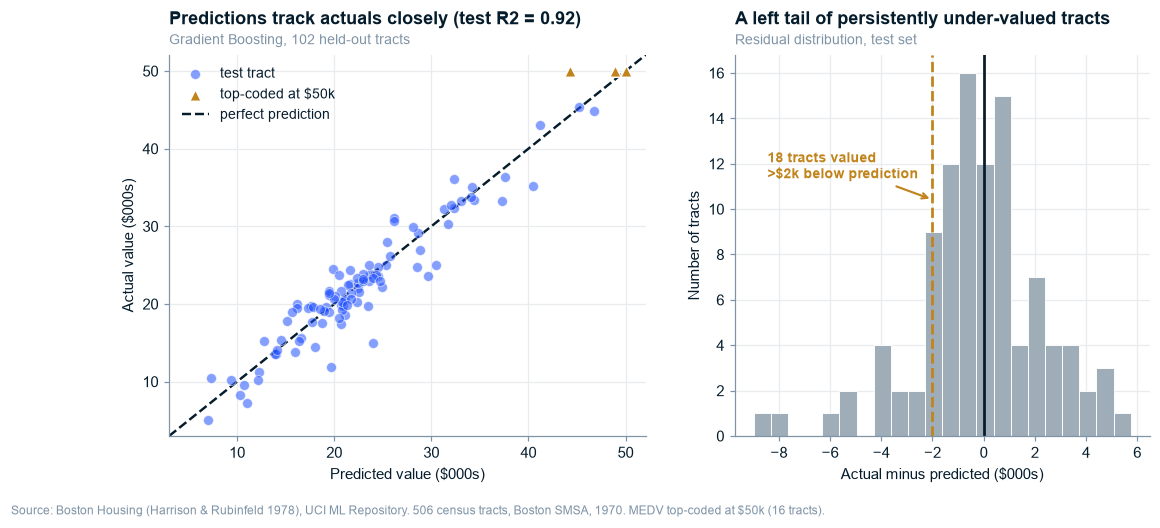

In [19]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11.5, 4.5),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# Left: predicted vs actual, the honest picture of model fit.
ok = resid.is_MEDV_censored == 0
axl.scatter(resid.loc[ok, "pred"], resid.loc[ok, TARGET], s=42, color=EMPHASIS, alpha=0.55,
            edgecolors=WHITE, linewidths=0.6, label="test tract", zorder=3)
axl.scatter(resid.loc[~ok, "pred"], resid.loc[~ok, TARGET], s=58, color=REFERENCE, marker="^",
            edgecolors=WHITE, linewidths=1.0, label="top-coded at $50k", zorder=4)
lims = [resid[[TARGET, "pred"]].min().min() - 2, resid[[TARGET, "pred"]].max().max() + 2]
axl.plot(lims, lims, color=NAVY, lw=1.6, ls="--", zorder=2, label="perfect prediction")
axl.set_xlim(lims); axl.set_ylim(lims)
axl.set_xlabel("Predicted value ($000s)"); axl.set_ylabel("Actual value ($000s)")
axl.legend(loc="upper left")
action_title(axl, f"Predictions track actuals closely (test R2 = {r2_without:.2f})",
             f"{WINNER}, {len(resid)} held-out tracts")

# Right: the residual distribution, with the targeting threshold marked.
axr.hist(resid.residual, bins=22, color=CONTEXT, edgecolor=WHITE, linewidth=0.6)
axr.axvline(0, color=NAVY, lw=1.8)
axr.axvline(-2, color=REFERENCE, lw=1.8, ls="--")
axr.annotate(f"{int((resid.residual < -2).sum())} tracts valued\n>$2k below prediction",
             xy=(-2, axr.get_ylim()[1] * 0.62), xytext=(-108, 14), textcoords="offset points",
             fontsize=9, color=REFERENCE, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=REFERENCE, lw=1.4))
axr.set_xlabel("Actual minus predicted ($000s)"); axr.set_ylabel("Number of tracts")
action_title(axr, "A left tail of persistently under-valued tracts", "Residual distribution, test set")

source_note(fig, SOURCE)
fig.savefig(FIGS / "ex07_residuals.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

> **So What:** a subset of test tracts sit materially below the value their own attributes predict.
> These are exactly the neighbourhoods where something *other than* composition and housing stock is
> suppressing value — the highest-information candidates for a site visit.
>
> **Implication — and the boundary of what this analysis licenses.** The residual list is a
> **targeting** device: it says *look here first*. It does **not** say what to change, because
> nothing in a 1970 cross-section identifies a causal effect. Any intervention decision needs a Path C
> design.

## 4.12 Persist the model and every number the report will quote

In [20]:
import pickle

with open(MODELS / "winning_model.pkl", "wb") as fh:
    pickle.dump(best_pipe, fh)

(MODELS / "model_card.json").write_text(json.dumps({
    "model": WINNER,
    "target": "MEDV (median tract home value, $1000s, 1970)",
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "validation": "RepeatedKFold(10 splits x 3 repeats), test set scored once",
    "test_r2": float(final.iloc[0].test_r2),
    "test_rmse_k": float(final.iloc[0].test_rmse),
    "excluded_features": {"B": "race-derived, barred at Stage 1",
                          "TAX": "linear spec only -- r=0.91 with RAD"},
    "random_state": RANDOM_STATE,
    "limitations": [
        "1970 cross-section; not valid for present-day valuation",
        "MEDV top-coded at $50k -- high-end effects are attenuated lower bounds",
        "association only; no causal identification, so no intervention claim is supported",
        "retained features reconstruct the race-derived B column, so the model is blind to race, "
        "not neutral about it; unsuitable for allocation between demographic groups",
    ],
}, indent=2))

# Tables the report renders directly.
final.to_csv(REPORTS / "_model_results.csv", index=False)
imp.to_csv(REPORTS / "_feature_importance.csv", index=False)
tests.to_csv(REPORTS / "_stat_tests.csv", index=False)
subgroup.to_csv(REPORTS / "_fairness_audit.csv")
under.to_csv(REPORTS / "_targeting_list.csv")

key("median_value_k", round(float(df[TARGET].median()), 1))
key("value_range_low_k", round(float(df[TARGET].min()), 1))
key("value_range_high_k", round(float(df[TARGET].max()), 1))
key("n_censored", int(df.is_MEDV_censored.sum()))
key("lstat_r", round(float(tests.query("feature=='LSTAT'").pearson_r.iloc[0]), 3))
key("rm_r", round(float(tests.query("feature=='RM'").pearson_r.iloc[0]), 3))
key("lstat_r2_alone", round(float(tests.query("feature=='LSTAT'").r_squared_alone.iloc[0]), 3))
key("rm_r2_alone", round(float(tests.query("feature=='RM'").r_squared_alone.iloc[0]), 3))
key("nonlinear_gain_pts", round((float(final.iloc[0].test_r2) - float(final.query("model=='OLS'").test_r2.iloc[0])) * 100, 1))

with open(REPORTS / "_key_figures.json", "w") as fh:
    json.dump(KEY, fh, indent=2, default=str)

print(f"persisted {len(KEY)} key figures for the report")
pd.Series(KEY).to_frame("value")

persisted 40 key figures for the report


,value
n_tests,11
n_significant_fdr,11
n_material,9
lstat_iqr_effect_k,-9.51
rm_iqr_effect_k,6.72
n_total,506
n_train,404
n_test,102
cv_folds,30
winning_model,Gradient Boosting


---

## Gate Checklists

### Stage 5a — Statistical Testing
- [x] **Tests selected on data characteristics** — Pearson *and* Spearman reported together, the gap used as a curvature diagnostic; Welch + Mann-Whitney for the unequal-variance, unequal-n `CHAS` comparison in §3.7
- [x] **Assumptions checked and documented** — skew measured (§3.1), non-linearity quantified (§3.3), multicollinearity quantified by VIF (§3.5)
- [x] **Effect sizes reported alongside p-values** — 95% CIs on every r, variance-explained per feature, Cohen's d for `CHAS`
- [x] **Multiple comparison correction applied** — Benjamini–Hochberg FDR across all 13 tests
- [x] **Results interpreted in business terms** — §4.2 restates every material association in dollars per IQR move

### Stage 4 — Feature Engineering
- [x] **Decisions documented with rationale** — every engineered feature traces to a numbered EDA finding
- [x] **No data leakage** — all fitted transforms live inside the `Pipeline`, fitted per CV fold; engineered features are row-wise and stateless
- [x] **Feature selection analysis completed** — permutation importance (§4.8); `TAX` dropped from the linear spec on VIF grounds
- [x] **Transformations reproducible** — a single `engineer()` function plus `ColumnTransformer`, no ad-hoc steps

### Stage 6 — Evaluation
- [x] **Evaluated on a held-out test set** — 20%, scored once after model selection
- [x] **Multiple metrics reported** — R², adjusted R², RMSE, MAE, CV and test side by side
- [x] **Compared against a meaningful baseline** — `DummyRegressor`; RMSE improvement quantified
- [x] **Business impact quantified** — error stated in $000s against a $22.5k median tract value
- [x] **Limitations documented** — model card lists four, including the fairness limitation
- [x] **Reproducibility confirmed** — `RANDOM_STATE=42` throughout, pinned dependencies, relative paths

### Cross-Cutting — Ethics, Fairness, Privacy
- [x] **Sensitive data classified and handled** — `B` classified at Stage 1, excluded from all models
- [x] **Data lineage documented** — SHA-256 → cleaning log → dtype contract → this notebook
- [x] **Fairness audit completed** — three tests: exclusion cost, proxy reconstruction, error by subgroup
- [x] **Proxy-feature and leakage review completed** — §4.9; the finding is adverse and is reported as such
- [x] **Monitoring plan** — N/A by design: a one-off 1970 analysis, not a deployed model. Recorded rather than skipped.
- [x] **Limitations and ethical risks surfaced in the report** — carried into the main narrative, not the appendix

**Gate status: PASS → proceed to `05_reporting.ipynb`.**

### Changelog
| Pass | Date | Change |
|---|---|---|
| 1 | 2026-07-20 | Path A tests, feature engineering, six-model bake-off, fairness audit, censoring sensitivity, residual targeting list. |